<a href="https://colab.research.google.com/github/CYBki/Research_papers/blob/main/Copy_of_paligemma2_deney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PaliGemma 2 küçük deney: çözünürlük ve Türkçe tabelalar

Bu defter, "Resimden Cevaba: PaliGemma 2'nin İçinden Bir Yolculuk" yazısındaki deneyin kodu. `paligemma2-3b-mix` modelinin **224** ve **448** piksellik sürümlerini, doğru cevabı önceden bilinen üç resim grubunda karşılaştırıyor.

**A. Gerçek Türkçe tabelalar (kendi fotoğraflarım):** Telefonla çektiğim tabela fotoğrafları ve üzerlerinde yazan metin, Drive klasöründen iniyor. Her fotoğrafta iki şey ölçülüyor:
- OCR (`ocr` görevi): çıktının gerçek metne göre **karakter hata oranı (CER)**, 0 kusursuz demek. Türkçe harfler (ç, ğ, ı, ö, ş, ü) Latin karşılığına çevrildikten sonra yeniden hesaplanan CER, hataların ne kadarının bu harflerden geldiğini gösteriyor.
- Aynı soru iki dilde: "tabelada ne yazıyor?" / "what is written on the sign?".

**B. Gerçek fotoğraflar, İngilizce (TextVQA):** [TextVQA](https://textvqa.org/) doğrulama setinden ilk 50 soru. Her soru için 10 insan cevabı var. Ölçü standart VQA doğruluğu: cevap, 10 insandan en az 3'üyle aynıysa tam puan alır. Makalenin "metin okumada çözünürlük kazanır" bulgusunu, makalenin kullandığı türden veriyle sınıyor.

**C. Yazı boyu (sentetik):** 12 Türkçe tabela metni kod içinde üç yazı boyunda resme basılıyor. Fotoğrafta kontrol edilemeyen tek değişkeni, yazının resimdeki büyüklüğünü kontrol ediyor.

**Notlar:**
- Mix modelleri TextVQA'nın *eğitim* bölümüyle ince ayarlandı. Burada kullanılan *doğrulama* bölümü eğitimde yok.
- C'deki tabelalar gerçek fotoğraf değil, düz zemin üstünde temiz yazı.
- Çıktılar `do_sample=False` ile alınıyor, yani her çalıştırmada aynı. Yalnızca süreler değişir.

**Çalıştırmadan önce:**
1. `Runtime > Change runtime type > T4 GPU` seç.
2. [paligemma2-3b-mix-224](https://huggingface.co/google/paligemma2-3b-mix-224) ve [paligemma2-3b-mix-448](https://huggingface.co/google/paligemma2-3b-mix-448) sayfalarında Gemma lisansını kabul et.
3. [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) adresinden bir *read* token al, soldaki anahtar simgesinden `HF_TOKEN` adıyla ekle.
4. `Runtime > Run all`. T4'te yaklaşık 15 dakika sürer.

In [ ]:
#!pip -q install -U "transformers>=4.47" accelerate datasets pillow pillow-heif gdown python-docx

In [ ]:
import os, re, time, random, torch, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageOps
from huggingface_hub import login
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor
try:
    from pillow_heif import register_heif_opener; register_heif_opener()  # iPhone HEIC fotoğrafları için
except ImportError:
    pass
try:
    from google.colab import userdata
    login(userdata.get('HF_TOKEN'))
except Exception as e:
    print('HF_TOKEN secret bulunamadı, login() ile elle giriş yap:', e)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'GPU yok!')
os.makedirs('images', exist_ok=True)
pd.set_option('display.max_colwidth', 60)

Tesla T4


## Yardımcı fonksiyonlar

In [ ]:
def yukle(model_id):
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, device_map='cuda').eval()
    proc = PaliGemmaProcessor.from_pretrained(model_id)
    sor(model, proc, Image.new('RGB', (64, 64)), 'caption en', max_new_tokens=4)  # ısınma
    return model, proc

@torch.inference_mode()
def sor(model, proc, image, prompt, max_new_tokens=32):
    inputs = proc(text=prompt, images=image, return_tensors='pt').to(torch.bfloat16).to(model.device)
    n = inputs['input_ids'].shape[-1]
    torch.cuda.synchronize(); t0 = time.time()
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    torch.cuda.synchronize(); sure = time.time() - t0
    uretilen = out.shape[-1] - n
    return proc.decode(out[0][n:], skip_special_tokens=True).strip(), sure, n, uretilen

def tr_kucuk(s):  # Türkçeye uygun küçük harf: İ→i, I→ı
    return (s or '').replace('İ', 'i').replace('I', 'ı').lower()

def sade(s):  # küçük harf, noktalama yok, satır sonları boşluk, tek boşluk
    s = re.sub(r'[^\w\s]', ' ', tr_kucuk(s))
    return ' '.join(s.split())

TR2ASCII = str.maketrans('çğıöşü', 'cgiosu')
def ascii_yap(s):
    return sade(s).translate(TR2ASCII)

def levenshtein(a, b):
    onceki = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        simdi = [i]
        for j, cb in enumerate(b, 1):
            simdi.append(min(onceki[j] + 1, simdi[j - 1] + 1, onceki[j - 1] + (ca != cb)))
        onceki = simdi
    return onceki[-1]

def cer(tahmin, gercek):  # karakter hata oranı: 0 kusursuz; tekrar eden çıktılarda 1'i aşabilir
    return levenshtein(tahmin, gercek) / max(1, len(gercek))

def metin_olc(cikti, gercek):
    return dict(cer=round(cer(sade(cikti), sade(gercek)), 3),
                cer_turkce_harfsiz=round(cer(ascii_yap(cikti), ascii_yap(gercek)), 3),
                tam_dogru=sade(cikti) == sade(gercek))

def vqa_dogruluk(tahmin, cevaplar):  # standart VQA ölçüsü: en az 3 insanla aynı cevap = 1 puan
    t = sade(tahmin)
    return min(1.0, sum(sade(c) == t for c in cevaplar) / 3)

## A. Gerçek Türkçe tabelalar: Drive klasörü
Klasör "bağlantıya sahip herkes görüntüleyebilir" olarak paylaşılmış olmalı. Yazılar klasördeki bir tablo (csv/xlsx), resimle aynı adlı .txt dosyaları ya da tek bir .txt dosyasındaki `dosya: yazı` satırlarından okunuyor.

15 resim, 17 diğer dosya: ['kaynaklar.txt', 'tabela_01.txt', 'tabela_02.txt', 'tabela_03.txt', 'tabela_04.txt', 'tabela_05.txt', 'tabela_06.txt', 'tabela_07.txt', 'tabela_08.txt', 'tabela_09.txt', 'tabela_10.txt', 'tabela_11.txt', 'tabela_12.txt', 'tabela_13.txt', 'tabela_14.txt', 'tabela_15.txt', 'tum_yazilar.txt']


,dosya,metin
0,tabela_01.jpg,//commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_ta...
1,tabela_02.jpg,"//commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,..."
2,tabela_03.jpg,//commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabela...
3,tabela_04.jpg,//commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg
4,tabela_05.jpg,//commons.wikimedia.org/wiki/File:Milyon_taşı_ve_tabelal...
5,tabela_06.jpg,//commons.wikimedia.org/wiki/File:SAKLI_EV_SOKAĞI_-_pano...
6,tabela_07.jpg,//commons.wikimedia.org/wiki/File:Çınarcık_Sign_03.06.20...
7,tabela_08.jpg,//commons.wikimedia.org/wiki/File:AKÇAY_MAKİNA.jpg
8,tabela_09.jpg,//commons.wikimedia.org/wiki/File:Ali_Muhiddin_Hacı_Beki...
9,tabela_10.jpg,//commons.wikimedia.org/wiki/File:ŞAPKACININ_DAMADI_ARİF...


Yukarıdaki yazılar doğru mu? Yanlışsa klasördeki yazı dosyasını düzeltip bu hücreyi tekrar çalıştır.


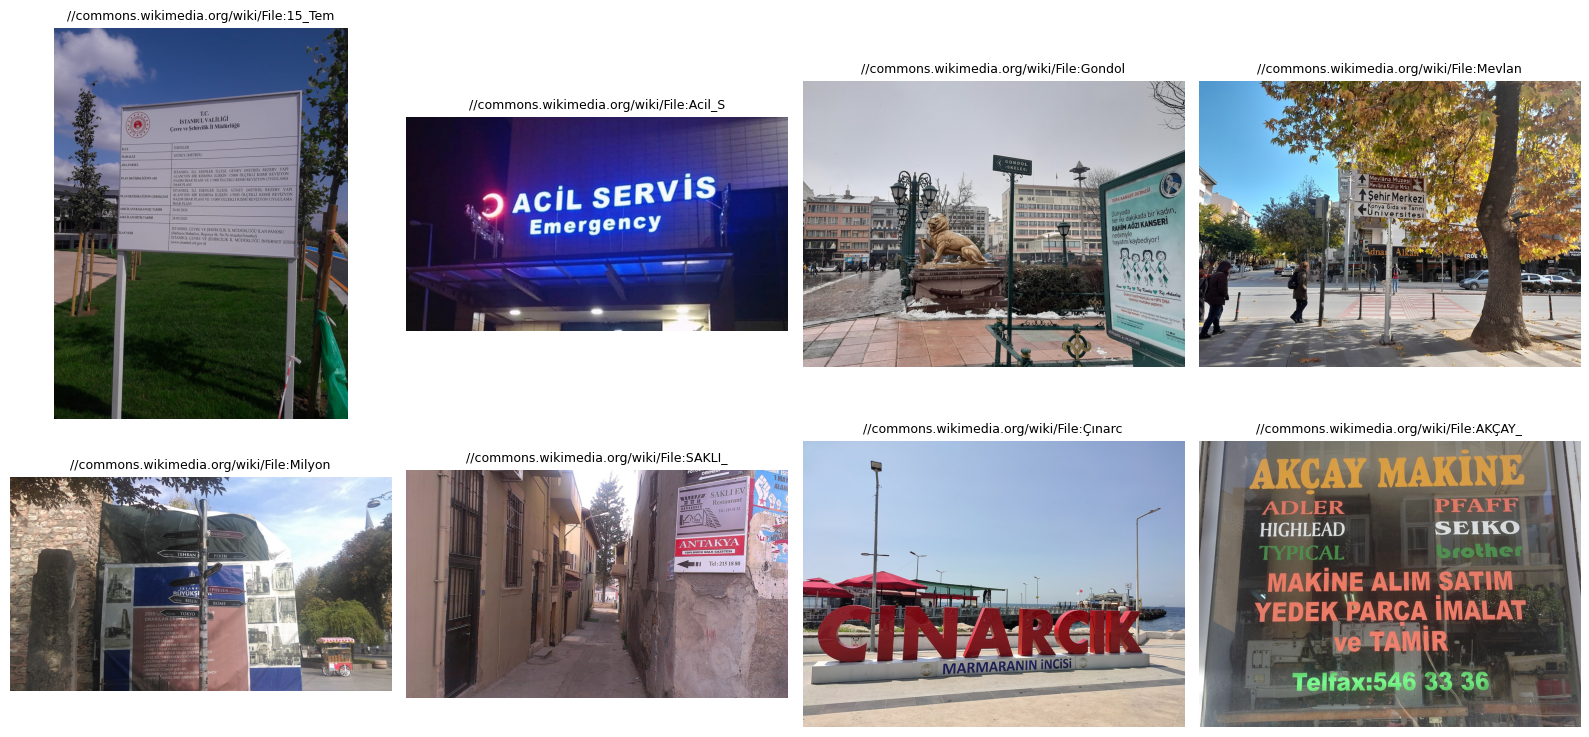

In [ ]:
# --- Tabela klasörünü indir ---
KLASOR_ID = '1xScrVG7L9cOuXKzvDafSSD5jwszIevE8'
KLASOR = 'tabela_klasoru'
RESIM_UZANTI = ('.jpg', '.jpeg', '.png', '.webp', '.heic', '.heif')
if not os.path.isdir(KLASOR) or not os.listdir(KLASOR):
    try:
        import gdown
        gdown.download_folder(id=KLASOR_ID, output=KLASOR, quiet=True)
    except Exception as e:
        print('gdown ile indirilemedi:', repr(e))
        print("Klasörü Drive'dan bağlamayı deniyorum (Drive'ındaki klasör adı 'tabela' varsayıldı).")
        from google.colab import drive
        drive.mount('/content/drive')
        KLASOR = '/content/drive/MyDrive/tabela'

dosyalar = sorted(os.path.join(k, f) for k, _, fs in os.walk(KLASOR) for f in fs)
resimler = [f for f in dosyalar if f.lower().endswith(RESIM_UZANTI)]
print(len(resimler), 'resim,', len(dosyalar) - len(resimler), 'diğer dosya:',
      [os.path.basename(f) for f in dosyalar if f not in resimler])

# --- Her resmin üzerindeki yazıyı bul ---
# Desteklenen biçimler: (1) csv/tsv/xlsx tablo (dosya adı + yazı sütunu), (2) resimle aynı adlı .txt,
# (3) tek bir .txt/.docx içinde "dosya: yazı" / "dosya<TAB>yazı" / "dosya - yazı" satırları, (4) son çare: dosya adı.
kok = lambda f: os.path.splitext(os.path.basename(f))[0].strip().lower()
resim_kokleri = {kok(r): r for r in resimler}
YAZILAR = {}

for f in dosyalar:  # (1) tablo
    uz = f.lower().rsplit('.', 1)[-1]
    if uz not in ('csv', 'tsv', 'xlsx', 'xls'): continue
    if uz.startswith('xls'):
        t = pd.read_excel(f)
    elif uz == 'tsv':
        t = pd.read_csv(f, sep='\t')
    else:
        t = pd.read_csv(f)
        if t.shape[1] < 2: t = pd.read_csv(f, sep=';')
    t = t.astype(str)
    dosya_sut = max(t.columns, key=lambda c: t[c].map(kok).isin(resim_kokleri).sum())
    yazi_sut = [c for c in t.columns if c != dosya_sut][0]
    for d, y in zip(t[dosya_sut], t[yazi_sut]):
        if kok(d) in resim_kokleri: YAZILAR[kok(d)] = y.strip()

def metni_oku(f):
    if f.lower().endswith('.docx'):
        import docx
        return '\n'.join(p.text for p in docx.Document(f).paragraphs).strip()
    return open(f, encoding='utf-8-sig').read().strip()

for f in dosyalar:  # (2) ve (3) txt / docx
    if not f.lower().endswith(('.txt', '.docx')): continue
    icerik = metni_oku(f)
    if kok(f) in resim_kokleri:
        YAZILAR.setdefault(kok(f), icerik)
        continue
    for satir in icerik.splitlines():
        m = re.match(r'\s*([^\t:]+?)\s*(?:\t|:|\s-\s|=)\s*(.+)$', satir)
        if m and kok(m.group(1)) in resim_kokleri:
            YAZILAR.setdefault(kok(m.group(1)), m.group(2).strip().strip('"'))

eksik = [k for k in resim_kokleri if k not in YAZILAR]
if eksik:
    print(len(eksik), 'resim için yazı dosyası bulunamadı, dosya adı yazı olarak kullanılıyor:', eksik)
    for k in eksik:
        YAZILAR[k] = os.path.splitext(os.path.basename(resim_kokleri[k]))[0].replace('_', ' ')

def ac(yol):  # telefon fotoğraflarını doğru yönde aç
    return ImageOps.exif_transpose(Image.open(yol)).convert('RGB')

GERCEK_TABELALAR = [dict(dosya=os.path.basename(resim_kokleri[k]), yol=resim_kokleri[k], metin=YAZILAR[k])
                    for k in sorted(resim_kokleri)]
display(pd.DataFrame(GERCEK_TABELALAR)[['dosya', 'metin']])
print('Yukarıdaki yazılar doğru mu? Yanlışsa klasördeki yazı dosyasını düzeltip bu hücreyi tekrar çalıştır.')

n = min(8, len(GERCEK_TABELALAR))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.flat: ax.axis('off')
for ax, o in zip(axes.flat, GERCEK_TABELALAR[:n]):
    ax.imshow(ac(o['yol'])); ax.set_title(o['metin'][:40], fontsize=9)
plt.tight_layout(); plt.show()

## B. Gerçek fotoğraflar, İngilizce: TextVQA doğrulama setinden 50 soru
Veri seti Hugging Face'ten akış (streaming) ile okunuyor, yalnızca ilk 50 örnek iniyor.

In [ ]:
from datasets import load_dataset
N_TEXTVQA = 50
TEXTVQA = []
try:
    ds = load_dataset('lmms-lab/textvqa', split='validation', streaming=True)
    for i, ex in enumerate(ds.take(N_TEXTVQA)):
        dosya = f'textvqa_{i:02d}.jpg'
        ex['image'].convert('RGB').save(os.path.join('images', dosya), quality=92)
        TEXTVQA.append(dict(dosya=dosya, soru=ex['question'], cevaplar=list(ex['answers'])))
except Exception as e:
    print('TextVQA indirilemedi, B kısmı atlanacak:', repr(e))
print(len(TEXTVQA), 'TextVQA örneği hazır')

README.md:   0%|          | 0.00/2.00k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

50 TextVQA örneği hazır


## C. Yazı boyu: 12 Türkçe metin × 3 boy (sentetik)
Yazı boyu, 896 piksellik resmin kenarına oranla büyük harf yüksekliği: büyük %6, orta %3, küçük %1,5. 224 piksele küçültülünce küçük boy yazının harfleri yaklaşık 3 piksel kalıyor, 448'de 7 piksel.

36 sentetik tabela üretildi


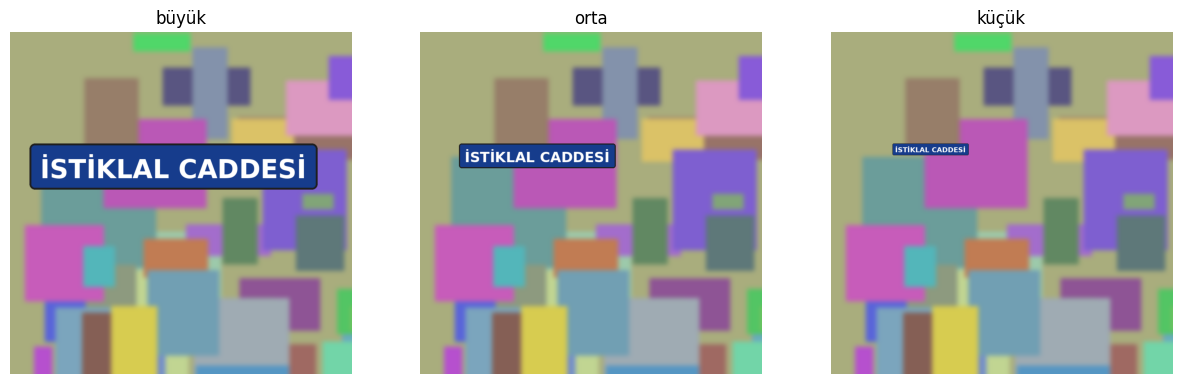

In [ ]:
FONT = os.path.join(os.path.dirname(matplotlib.__file__), 'mpl-data/fonts/ttf/DejaVuSans-Bold.ttf')
METINLER = [
    "İSTİKLAL CADDESİ", "ŞİŞLİ ECZANESİ", "KAPALIÇARŞI", "ÜSKÜDAR İSKELESİ",
    "ÇIKIŞ", "DİKKAT KAYGAN ZEMİN", "GÜZELYALI ÇAY BAHÇESİ", "ÖĞRETMENLER LOKALİ",
    "Taze Simit 15 TL", "Kuyumcu Ağaoğlu", "Mısır Çarşısı", "Şehir Hatları",
]
# Yazı yüksekliği, 896 piksellik resmin kenarına oranla (büyük / orta / küçük)
BOYLAR = {'büyük': 0.06, 'orta': 0.03, 'küçük': 0.015}
RENKLER = [((22, 60, 140), (255, 255, 255)), ((180, 30, 30), (255, 255, 255)),
           ((20, 110, 60), (255, 255, 255)), ((250, 210, 40), (20, 20, 20)), ((245, 245, 240), (25, 25, 25))]

def sahne(metin, boy, tohum, kenar=896):
    rnd = random.Random(tohum)
    # Arka plan: rastgele dikdörtgenlerle "bina cephesi" benzeri doku
    img = Image.new('RGB', (kenar, kenar), tuple(rnd.randint(120, 200) for _ in range(3)))
    d = ImageDraw.Draw(img)
    for _ in range(40):
        x, y = rnd.randint(0, kenar), rnd.randint(0, kenar)
        w, h = rnd.randint(40, 300), rnd.randint(40, 300)
        d.rectangle([x, y, x + w, y + h], fill=tuple(rnd.randint(80, 220) for _ in range(3)))
    img = img.filter(ImageFilter.GaussianBlur(6))
    d = ImageDraw.Draw(img)
    # Tabela
    punto = int(BOYLAR[boy] * kenar / 0.72)  # büyük harf yüksekliği ≈ 0.72 × punto
    while True:  # uzun metinlerde tabela resme sığana kadar küçült
        font = ImageFont.truetype(FONT, punto)
        l, t, r, b = d.textbbox((0, 0), metin, font=font)
        if (r - l) * 1.15 < kenar * 0.9 or punto < 8: break
        punto -= 2
    tw, th = r - l, b - t
    pad = max(6, int(th * 0.45))
    zemin, yazi = RENKLER[tohum % len(RENKLER)]
    x0 = rnd.randint(int(kenar * 0.05), max(int(kenar * 0.05), kenar - tw - 2 * pad - int(kenar * 0.05)))
    y0 = rnd.randint(int(kenar * 0.15), int(kenar * 0.75))
    d.rounded_rectangle([x0, y0, x0 + tw + 2 * pad, y0 + th + 2 * pad], radius=pad // 2, fill=zemin,
                        outline=(30, 30, 30), width=max(1, pad // 5))
    d.text((x0 + pad - l, y0 + pad - t), metin, font=font, fill=yazi)
    return img

TABELALAR = []
for i, metin in enumerate(METINLER):
    for boy in BOYLAR:
        dosya = f'sentetik_{i:02d}_{boy}.png'
        sahne(metin, boy, tohum=i).save(os.path.join('images', dosya))
        TABELALAR.append(dict(dosya=dosya, metin=metin, boy=boy))
print(len(TABELALAR), 'sentetik tabela üretildi')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, boy in zip(axes, BOYLAR):
    ax.imshow(Image.open(os.path.join('images', f'sentetik_00_{boy}.png'))); ax.set_title(boy); ax.axis('off')
plt.show()

## Modelleri çalıştır
Her model bir kez yükleniyor ve A, B, C'nin hepsini yapıyor. Önce 224, sonra 448.

In [ ]:
MAX_OCR = 64  # bu sınıra dayanan OCR çıktısı kendini tekrar ediyor demektir
sonuc_a_ocr, sonuc_a_dil, sonuc_b, sonuc_c = [], [], [], []
for model_id in ['google/paligemma2-3b-mix-224', 'google/paligemma2-3b-mix-448']:
    if 'model' in globals():
        del model; torch.cuda.empty_cache()
    model, proc = yukle(model_id)
    px = model_id.split('-')[-1] + ' px'
    print('Model:', px)

    for o in GERCEK_TABELALAR:  # A
        img = ac(o['yol'])
        cikti, sure, n, uretilen = sor(model, proc, img, 'ocr', max_new_tokens=MAX_OCR)
        sonuc_a_ocr.append(dict(model=px, dosya=o['dosya'], gercek=o['metin'], cikti=cikti, **metin_olc(cikti, o['metin']),
                                dongu=uretilen >= MAX_OCR, sure_sn=round(sure, 2), girdi_token=n))
        for dil, soru in [('tr', 'tabelada ne yazıyor?'), ('en', 'what is written on the sign?')]:
            cevap, sure, n, _ = sor(model, proc, img, f'answer {dil} {soru}')
            sonuc_a_dil.append(dict(model=px, dil=dil, dosya=o['dosya'], gercek=o['metin'], cevap=cevap,
                                    **metin_olc(cevap, o['metin'])))

    for o in TEXTVQA:  # B
        cevap, sure, n, _ = sor(model, proc, Image.open(os.path.join('images', o['dosya'])), f"answer en {o['soru']}")
        sonuc_b.append(dict(model=px, dosya=o['dosya'], soru=o['soru'], cevap=cevap, insan_cevabi=o['cevaplar'][0],
                            dogruluk=vqa_dogruluk(cevap, o['cevaplar']), sure_sn=round(sure, 2), girdi_token=n))

    for o in TABELALAR:  # C
        cikti, sure, n, uretilen = sor(model, proc, Image.open(os.path.join('images', o['dosya'])), 'ocr', max_new_tokens=MAX_OCR)
        sonuc_c.append(dict(model=px, dosya=o['dosya'], boy=o['boy'], gercek=o['metin'], cikti=cikti,
                            **metin_olc(cikti, o['metin']), dongu=uretilen >= MAX_OCR))

df_a_ocr, df_a_dil = pd.DataFrame(sonuc_a_ocr), pd.DataFrame(sonuc_a_dil)
df_b, df_c = pd.DataFrame(sonuc_b), pd.DataFrame(sonuc_c)
print('Bitti.')

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/75.1k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Model: 448 px


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many i

Bitti.


## Sonuçlar
### A. Gerçek Türkçe tabelalar
**OCR, 224 ve 448.** `ortanca_cer` ile `ortanca_cer_turkce_harfsiz` arasındaki fark, yalnızca Türkçe harflerden gelen hata.

In [ ]:
if df_a_ocr.empty:
    print('A kısmında resim yok.')
else:
    display(df_a_ocr.groupby('model').agg(resim=('cer', 'size'), tam_dogru=('tam_dogru', 'sum'),
                                          ortanca_cer=('cer', 'median'), ortanca_cer_turkce_harfsiz=('cer_turkce_harfsiz', 'median'),
                                          dongu=('dongu', 'sum'), girdi_token=('girdi_token', 'first'),
                                          ortanca_sure_sn=('sure_sn', 'median')))
    display(df_a_ocr.pivot_table(index=['dosya', 'gercek'], columns='model', values=['cikti', 'cer'], aggfunc='first'))

,resim,tam_dogru,ortanca_cer,ortanca_cer_turkce_harfsiz,dongu,girdi_token,ortanca_sure_sn
model,,,,,,,
224 px,15,0,1.108,1.077,9,259,3.34
448 px,15,0,1.353,1.324,8,1027,5.34


cer  \
model                                                                      224 px   
dosya         gercek                                                                
tabela_01.jpg //commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_tab...  1.435   
tabela_02.jpg //commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,_...  0.806   
tabela_03.jpg //commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabelas...  1.683   
tabela_04.jpg //commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg   0.982   
tabela_05.jpg //commons.wikimedia.org/wiki/File:Milyon_taşı_ve_tabelala...  1.443   
tabela_06.jpg //commons.wikimedia.org/wiki/File:SAKLI_EV_SOKAĞI_-_panor...  1.063   
tabela_07.jpg //commons.wikimedia.org/wiki/File:Çınarcık_Sign_03.06.202...  0.810   
tabela_08.jpg //commons.wikimedia.org/wiki/File:AKÇAY_MAKİNA.jpg            2.000   
tabela_09.jpg //commons.wikimedia.org/wiki/File:Ali_Muhiddin_Hacı_Bekir...  1.108   
tabela_10.jpg //commons.wikimedia.org/wiki/File:ŞAPKACININ_DAMADI_ARİF_...  0.901   
tabela_11.jpg //commons.wikimedia.org/wiki/File:Mevsim_İklimlendirme_20...  0.808   
tabela_12.jpg //commons.wikimedia.org/wiki/File:Dukkan_gulciceksarayi.JPG   2.596   
tabela_13.jpg //commons.wikimedia.org/wiki/File:Arsacı_balaban_emlak_-_...  1.206   
tabela_14.jpg //commons.wikimedia.org/wiki/File:Tek-El_Tobacco_Konya.jpg    1.143   
tabela_15.jpg //commons.wikimedia.org/wiki/File:Aycell_-_Sıla_Izgara.jpg    0.696   

                                                                                   \
model                                                                      448 px   
dosya         gercek                                                                
tabela_01.jpg //commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_tab...  1.419   
tabela_02.jpg //commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,_...  0.806   
tabela_03.jpg //commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabelas...  1.900   
tabela_04.jpg //commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg   1.930   
tabela_05.jpg //commons.wikimedia.org/wiki/File:Milyon_taşı_ve_tabelala...  1.508   
tabela_06.jpg //commons.wikimedia.org/wiki/File:SAKLI_EV_SOKAĞI_-_panor...  1.302   
tabela_07.jpg //commons.wikimedia.org/wiki/File:Çınarcık_Sign_03.06.202...  0.810   
tabela_08.jpg //commons.wikimedia.org/wiki/File:AKÇAY_MAKİNA.jpg            2.354   
tabela_09.jpg //commons.wikimedia.org/wiki/File:Ali_Muhiddin_Hacı_Bekir...  0.938   
tabela_10.jpg //commons.wikimedia.org/wiki/File:ŞAPKACININ_DAMADI_ARİF_...  0.889   
tabela_11.jpg //commons.wikimedia.org/wiki/File:Mevsim_İklimlendirme_20...  1.014   
tabela_12.jpg //commons.wikimedia.org/wiki/File:Dukkan_gulciceksarayi.JPG   1.509   
tabela_13.jpg //commons.wikimedia.org/wiki/File:Arsacı_balaban_emlak_-_...  1.353   
tabela_14.jpg //commons.wikimedia.org/wiki/File:Tek-El_Tobacco_Konya.jpg    0.750   
tabela_15.jpg //commons.wikimedia.org/wiki/File:Aycell_-_Sıla_Izgara.jpg    2.107   

                                                                                                                                  cikti  \
model                                                                                                                            224 px   
dosya         gercek                                                                                                                      
tabela_01.jpg //commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_tab...  T.C.\nİSTANBUL ÜNİVERSİTESİ\nÇevre ve Şehircilik Bölümü\...   
tabela_02.jpg //commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,_...                                       ACİL SERVİS\nEmergency   
tabela_03.jpg //commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabelas...  E. TANDEN\nSTRAND\nwww.tandenstadtsport.nl\nDe nieuwe\ns...   
tabela_04.jpg //commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg   P\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\nP\...   
tabela_05.jpg //commons.wikimedia.org/wiki/

**Aynı tabela, iki dilde soru.**

In [ ]:
if not df_a_dil.empty:
    display(df_a_dil.groupby(['model', 'dil']).agg(tam_dogru=('tam_dogru', 'sum'), ortanca_cer=('cer', 'median'),
                                                   ortanca_cer_turkce_harfsiz=('cer_turkce_harfsiz', 'median')))
    display(df_a_dil.pivot_table(index=['dosya', 'gercek'], columns=['model', 'dil'], values='cevap', aggfunc='first'))

tam_dogru  ortanca_cer  ortanca_cer_turkce_harfsiz
model  dil                                                    
224 px en           0        0.867                       0.867
       tr           0        0.853                       0.853
448 px en           0        0.867                       0.867
       tr           0        0.833                       0.824

model                                                                                           224 px  \
dil                                                                                                 en   
dosya         gercek                                                                                     
tabela_01.jpg //commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_tab...                unanswerable   
tabela_02.jpg //commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,_...       acil servis emergency   
tabela_03.jpg //commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabelas...                unanswerable   
tabela_04.jpg //commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg             centro comercial   
tabela_05.jpg //commons.wikimedia.org/wiki/File:Milyon_taşı_ve_tabelala...                unanswerable   
tabela_06.jpg //commons.wikimedia.org/wiki/File:SAKLI_EV_SOKAĞI_-_panor...                     antalya   
tabela_07.jpg //commons.wikimedia.org/wiki/File:Çınarcık_Sign_03.06.202...                    cinarcik   
tabela_08.jpg //commons.wikimedia.org/wiki/File:AKÇAY_MAKİNA.jpg                          akcay makine   
tabela_09.jpg //commons.wikimedia.org/wiki/File:Ali_Muhiddin_Hacı_Bekir...  ali muhabbetli hasir bekir   
tabela_10.jpg //commons.wikimedia.org/wiki/File:ŞAPKACININ_DAMADI_ARİF_...                  pasa sapka   
tabela_11.jpg //commons.wikimedia.org/wiki/File:Mevsim_İklimlendirme_20...                     mevisia   
tabela_12.jpg //commons.wikimedia.org/wiki/File:Dukkan_gulciceksarayi.JPG             gul cicek sarayı   
tabela_13.jpg //commons.wikimedia.org/wiki/File:Arsacı_balaban_emlak_-_...               balaban emlak   
tabela_14.jpg //commons.wikimedia.org/wiki/File:Tek-El_Tobacco_Konya.jpg              the best tobacco   
tabela_15.jpg //commons.wikimedia.org/wiki/File:Aycell_-_Sıla_Izgara.jpg                        aycell   

model                                                                                                                     \
dil                                                                                                                   tr   
dosya         gercek                                                                                                       
tabela_01.jpg //commons.wikimedia.org/wiki/File:15_Temmuz_Mahallesi_tab...                                  unanswerable   
tabela_02.jpg //commons.wikimedia.org/wiki/File:Acil_Servis_Tabelası_,_...                         acil servis emergency   
tabela_03.jpg //commons.wikimedia.org/wiki/File:Gondol_iskelesi_tabelas...        "şükran günü" ve "milli marş" yazıyor.   
tabela_04.jpg //commons.wikimedia.org/wiki/File:Mevlana_müzesi_tabela.jpg     sahin merkezi, şehir merkezi, universitesi   
tabela_05.jpg //commons.wikimedia.org/wiki/File:Milyon_taşı_ve_tabelala...                                  unanswerable   
tabela_06.jpg //commons.wikimedia.org/wiki/File:SAKLI_EV_SOKAĞI_-_panor...                                       antalya   
tabela_07.jpg //commons.wikimedia.org/wiki/File:Çınarcık_Sign_03.06.202...                                      cinarcik   
tabela_08.jpg //commons.wikimedia.org/wiki/File:AKÇAY_MAKİNA.jpg                                            unanswerable   
tabela_09.jpg //commons.wikimedia.org/wiki/File:Ali_Muhiddin_Hacı_Bekir...                     m.h. mabettin hasir bekir   
tabela_10.jpg //commons.wikimedia.org/wiki/File:ŞAPKACININ_DAMADI_ARİF_...  "pasa sahra" (kaldırımda alışveriş) yazıyor.   
tabela_11.jpg //commons.wikimedia.org/wiki/File:Mevsim_İklimlendirme_20...                                       mevisia   
tabela_12.jpg //commons.wikimedia.org/wiki/File:Dukkan_gulciceksarayi.JPG                               gul cicek sarayı   
tabela_13.jpg //commons.wikimedia.org/wiki/File:Arsacı_balaban_emlak_-_...                                  balaban emek   
tabela_14.jpg //commons.wikimedia.org/wiki/File:Tek-El_Tobacco_Konya.jpg                       "tork-e-toba

### B. TextVQA: çözünürlük metin okumayı iyileştiriyor mu?

In [ ]:
if df_b.empty:
    print('B kısmı çalışmadı (TextVQA inmedi).')
else:
    display(df_b.groupby('model').agg(soru=('dogruluk', 'size'), vqa_dogrulugu=('dogruluk', 'mean'),
                                      girdi_token=('girdi_token', 'first'), ortanca_sure_sn=('sure_sn', 'median')).round(3))
    gen = df_b.pivot(index=['dosya', 'soru'], columns='model', values=['cevap', 'dogruluk'])
    fark = gen[gen[('dogruluk', '224 px')] != gen[('dogruluk', '448 px')]]
    print(len(fark), 'soruda iki çözünürlüğün puanı farklı:')
    display(fark)

,soru,vqa_dogrulugu,girdi_token,ortanca_sure_sn
model,,,,
224 px,50,0.587,268,0.755
448 px,50,0.727,1036,2.680


10 soruda iki çözünürlüğün puanı farklı:


cevap  \
model                                                                                     224 px   
dosya          soru                                                                                
textvqa_04.jpg how long has the drink on the right been aged?                           10 years   
textvqa_18.jpg how many items can you get for $5?                                              2   
textvqa_23.jpg what does the screen say to do?                                select your option   
textvqa_29.jpg what is the name of this chapter?                                    einc's cross   
textvqa_34.jpg what is the screen name being displayed?                 new mention by @mediazar   
textvqa_35.jpg what does the picture say the other ride is?                          my favorite   
textvqa_38.jpg what is the title of the book?                               the closte's wetland   
textvqa_39.jpg what is the number of the runner in the lead right now?                     57858   
textvqa_40.jpg what is the number on the runner in middle?                                 57858   
textvqa_45.jpg what are the brand of cigarettes?                                        marlboro   

                                                                                               \
model                                                                                  448 px   
dosya          soru                                                                             
textvqa_04.jpg how long has the drink on the right been aged?                              10   
textvqa_18.jpg how many items can you get for $5?                                           3   
textvqa_23.jpg what does the screen say to do?                                    select your   
textvqa_29.jpg what is the name of this chapter?                                 king's cross   
textvqa_34.jpg what is the screen name being displayed?                          unanswerable   
textvqa_35.jpg what does the picture say the other ride is?                          your mom   
textvqa_38.jpg what is the title of the book?                           the cloisters wetland   
textvqa_39.jpg what is the number of the runner in the lead right now?                  57859   
textvqa_40.jpg what is the number on the runner in middle?                              57859   
textvqa_45.jpg what are the brand of cigarettes?                                       honghe   

                                                                       dogruluk  \
model                                                                    224 px   
dosya          soru                                                               
textvqa_04.jpg how long has the drink on the right been aged?               1.0   
textvqa_18.jpg how many items can you get for $5?                           0.0   
textvqa_23.jpg what does the screen say to do?                              0.0   
textvqa_29.jpg what is the name of this chapter?                            0.0   
textvqa_34.jpg what is the screen name being displayed?                     0.0   
textvqa_35.jpg what does the picture say the other ride is?                 0.0   
textvqa_38.jpg what is the title of the book?                               0.0   
textvqa_39.jpg what is the number of the runner in the lead right now?      0.0   
textvqa_40.jpg what is the number on the runner in middle?                  0.0   
textvqa_45.jpg what are the brand of cigarettes?                            0.0   

                                                                                  
model                                                                     448 px  
dosya          soru                                                               
textvqa_04.jpg how long has the drink on the right been aged?           0.333333  
textvqa_18.jpg how many items can you get for $5?                            1.0  
textvqa_23.jpg what does the scre

### C. Yazı boyu ve çözünürlük

In [ ]:
ozet_c = df_c.groupby(['boy', 'model']).agg(resim=('cer', 'size'), tam_dogru=('tam_dogru', 'sum'),
                                            ortanca_cer=('cer', 'median'), dongu=('dongu', 'sum'))
display(ozet_c.reindex(list(BOYLAR), level=0))

resim  tam_dogru  ortanca_cer  dongu
boy   model                                       
büyük 224 px     12         11       0.0000      0
      448 px     12         12       0.0000      0
orta  224 px     12          9       0.0000      0
      448 px     12         11       0.0000      0
küçük 224 px     12          2       0.2055      0
      448 px     12         10       0.0000      0

84 resim hazır


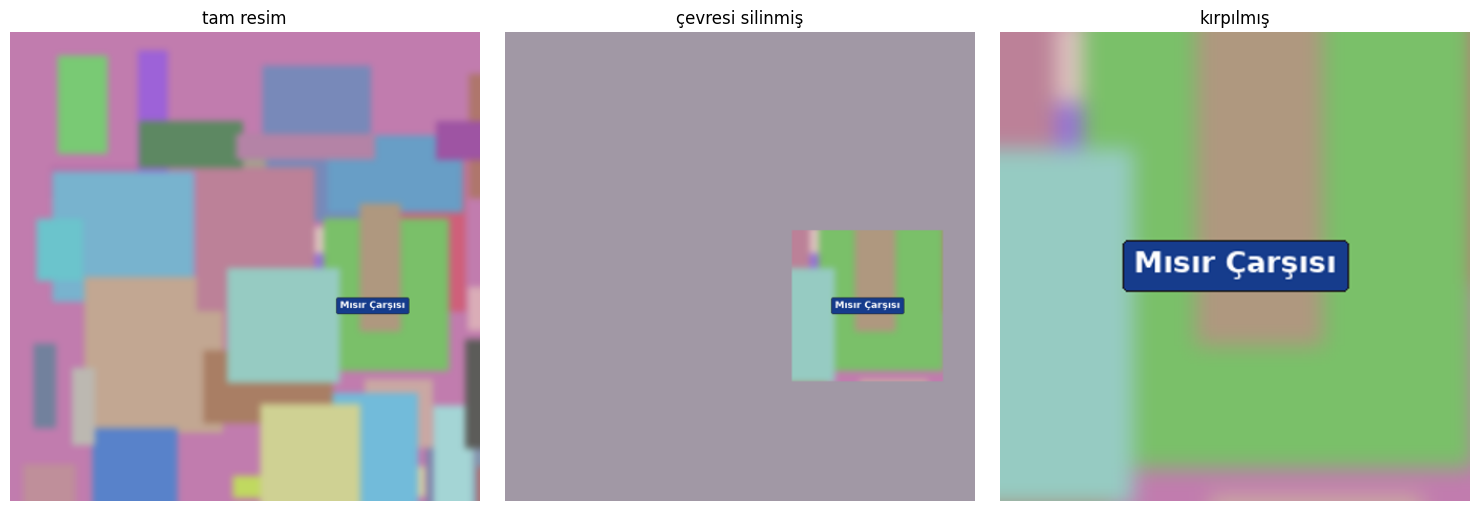

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Model: 224 px


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many i

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

...

Model: 448 px


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many i

resim  harf_px  tam_dogru  turkce_harf_hatasi  \
model  boy   kosul                                                             
224 px küçük tam resim            12     3.20          2                  10   
             çevresi silinmiş     12     3.20          2                  10   
             kırpılmış            12    10.10         11                   3   
       orta  tam resim            12     6.70          9                   5   
             çevresi silinmiş     12     6.70          9                   5   
             kırpılmış            12    10.40         11                   2   
       büyük tam resim            12    12.75         11                   2   
448 px küçük tam resim            12     6.50         10                   3   
             çevresi silinmiş     12     6.50         11                   2   
             kırpılmış            12    20.20         11                   2   
       orta  tam resim            12    13.30         11                   1   
             çevresi silinmiş     12    13.30         11                   1   
             kırpılmış            12    20.70         12                   0   
       büyük tam resim            12    25.55         12                   0   

                               diger_hata  dongu  
model  boy   kosul                                
224 px küçük tam resim                 35      0  
             çevresi silinmiş          25      0  
             kırpılmış                  0      0  
       orta  tam resim                  0      0  
             çevresi silinmiş           0      0  
             kırpılmış                  0      0  
       büyük tam resim                  0      0  
448 px küçük tam resim                  0      0  
             çevresi silinmiş           0      0  
             kırpılmış                  0      0  
       orta  tam resim                  0      0  
             çevresi silinmiş           0      0  
             kırpılmış                  0      0  
       büyük tam resim                  0      0

,model,boy,kosul,gercek,cikti,turkce_harf_hatasi,diger_hata
0,224 px,küçük,tam resim,İSTİKLAL CADDESİ,İSTIKAL CADDESİ,1,1
1,224 px,küçük,çevresi silinmiş,İSTİKLAL CADDESİ,İSTIKAL CADDESİ,1,1
7,224 px,küçük,tam resim,ŞİŞLİ ECZANESİ,ŞİRLİ İÇZANESI,2,2
8,224 px,küçük,çevresi silinmiş,ŞİŞLİ ECZANESİ,ŞİRLİ İÇZANESI,2,2
14,224 px,küçük,tam resim,KAPALIÇARŞI,KANLUCARD,1,5
15,224 px,küçük,çevresi silinmiş,KAPALIÇARŞI,KAPALICARDS,1,2
21,224 px,küçük,tam resim,ÜSKÜDAR İSKELESİ,USKODAR İSKELESİ,1,1
22,224 px,küçük,çevresi silinmiş,ÜSKÜDAR İSKELESİ,ÜSKÜDAR İSKELEĞİ,0,1
28,224 px,küçük,tam resim,ÇIKIŞ,CIRIS,2,1
29,224 px,küçük,çevresi silinmiş,ÇIKIŞ,CIRIS,2,1


Kaydedildi: sonuc_kirpma.csv, kirpma_ornek.png


In [ ]:
# D. Kırpma testi: Türkçe harf hataları pikselden mi, modelden mi?
#
# Colab'daki not defterinin en altına yeni bir kod hücresi ekleyip bu dosyanın tamamını yapıştır.
# Hücre tek başına çalışır: yeni bir oturumda önce en üstteki pip hücresini, sonra yalnızca bu hücreyi çalıştırman yeter.
# T4'te yaklaşık 10 dakika sürer. Sonunda sonuc_kirpma.csv dosyasını kaydeder.
#
# 448'in küçük yazıdaki hataları yalnızca Türkçe harflerdeydi ("Mısır" yerine "Misir").
# İki açıklama var: nokta ve çengeller resim küçültülünce piksellerde kayboluyor, ya da model harfi görüp alışık olduğu
# sade hâlini yazıyor. C kısmındaki sentetik tabelaların aynısı üç hâlde veriliyor:
#   tam resim        : C'deki resmin aynısı.
#   çevresi silinmiş : yazı aynı yerde ve aynı boyda, tabelanın çevresindeki kare dışında her yer düz renk (arka plan kontrolü).
#   kırpılmış        : tabelayı ortalayan kare kesilip veriliyor, yazı modelin girdisinde büyüyor (448'de yaklaşık 20 piksel).
# Kırpınca hatalar kaybolup çevresi silinince kalıyorsa sebep piksel, kırpınca da kalıyorsa sebep model.
# Büyük yazı yalnızca tam resim olarak, karşılaştırma için var.

import os, re, time, random, torch, matplotlib, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageStat
from huggingface_hub import login
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor
try:
    from google.colab import userdata
    login(userdata.get('HF_TOKEN'))
except Exception as e:
    print('HF_TOKEN secret bulunamadı, login() ile elle giriş yap:', e)

# --- Yardımcı fonksiyonlar (not defterindekilerin aynısı) ---
def yukle(model_id):
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, device_map='cuda').eval()
    proc = PaliGemmaProcessor.from_pretrained(model_id)
    sor(model, proc, Image.new('RGB', (64, 64)), 'caption en', max_new_tokens=4)  # ısınma
    return model, proc

@torch.inference_mode()
def sor(model, proc, image, prompt, max_new_tokens=32):
    inputs = proc(text=prompt, images=image, return_tensors='pt').to(torch.bfloat16).to(model.device)
    n = inputs['input_ids'].shape[-1]
    torch.cuda.synchronize(); t0 = time.time()
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    torch.cuda.synchronize(); sure = time.time() - t0
    uretilen = out.shape[-1] - n
    return proc.decode(out[0][n:], skip_special_tokens=True).strip(), sure, n, uretilen

def tr_kucuk(s):  # Türkçeye uygun küçük harf: İ→i, I→ı
    return (s or '').replace('İ', 'i').replace('I', 'ı').lower()

def sade(s):  # küçük harf, noktalama yok, satır sonları boşluk, tek boşluk
    s = re.sub(r'[^\w\s]', ' ', tr_kucuk(s))
    return ' '.join(s.split())

TR2ASCII = str.maketrans('çğıöşü', 'cgiosu')

def levenshtein(a, b):
    onceki = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        simdi = [i]
        for j, cb in enumerate(b, 1):
            simdi.append(min(onceki[j] + 1, simdi[j - 1] + 1, onceki[j - 1] + (ca != cb)))
        onceki = simdi
    return onceki[-1]

def hizala(a, b):  # Levenshtein hizalaması: a ve b'de birbirine eşlenen aynı karakterlerin (i, j) konumları
    D = [[i + j if i * j == 0 else 0 for j in range(len(b) + 1)] for i in range(len(a) + 1)]
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            D[i][j] = min(D[i - 1][j] + 1, D[i][j - 1] + 1, D[i - 1][j - 1] + (a[i - 1] != b[j - 1]))
    i, j, ciftler = len(a), len(b), []
    while i > 0 and j > 0:
        if D[i][j] == D[i - 1][j - 1] + (a[i - 1] != b[j - 1]):
            if a[i - 1] == b[j - 1]:
                ciftler.append((i - 1, j - 1))
            i, j = i - 1, j - 1
        elif D[i][j] == D[i - 1][j] + 1:
            i -= 1
        else:
            j -= 1
    return ciftler

def harf_olc(cikti, gercek):
    g, c = sade(gercek), sade(cikti)
    ga, ca = g.translate(TR2ASCII), c.translate(TR2ASCII)  # Türkçe harfler sade hâline çevrilmiş
    return dict(tam_dogru=g == c,
                # yalnızca ı/i, ş/s, ç/c, ğ/g, ö/o, ü/u karışmaları (ör. "Mısır" yerine "Misir" = 2)
                turkce_harf_hatasi=sum(g[i] != c[j] for i, j in hizala(ga, ca)),
                # Türkçe harfler sadeleştirildikten sonra da kalan hatalar (yanlış, eksik, fazla harf)
                diger_hata=levenshtein(ga, ca))

# --- C kısmındaki sentetik tabelaların aynısı (aynı kod, aynı tohumlar); tek fark tabelanın kutusunu da döndürmesi ---
FONT = os.path.join(os.path.dirname(matplotlib.__file__), 'mpl-data/fonts/ttf/DejaVuSans-Bold.ttf')
METINLER = [
    "İSTİKLAL CADDESİ", "ŞİŞLİ ECZANESİ", "KAPALIÇARŞI", "ÜSKÜDAR İSKELESİ",
    "ÇIKIŞ", "DİKKAT KAYGAN ZEMİN", "GÜZELYALI ÇAY BAHÇESİ", "ÖĞRETMENLER LOKALİ",
    "Taze Simit 15 TL", "Kuyumcu Ağaoğlu", "Mısır Çarşısı", "Şehir Hatları",
]
BOYLAR = {'büyük': 0.06, 'orta': 0.03, 'küçük': 0.015}
RENKLER = [((22, 60, 140), (255, 255, 255)), ((180, 30, 30), (255, 255, 255)),
           ((20, 110, 60), (255, 255, 255)), ((250, 210, 40), (20, 20, 20)), ((245, 245, 240), (25, 25, 25))]

def sahne_kutulu(metin, boy, tohum, kenar=896):
    rnd = random.Random(tohum)
    img = Image.new('RGB', (kenar, kenar), tuple(rnd.randint(120, 200) for _ in range(3)))
    d = ImageDraw.Draw(img)
    for _ in range(40):
        x, y = rnd.randint(0, kenar), rnd.randint(0, kenar)
        w, h = rnd.randint(40, 300), rnd.randint(40, 300)
        d.rectangle([x, y, x + w, y + h], fill=tuple(rnd.randint(80, 220) for _ in range(3)))
    img = img.filter(ImageFilter.GaussianBlur(6))
    d = ImageDraw.Draw(img)
    punto = int(BOYLAR[boy] * kenar / 0.72)  # büyük harf yüksekliği ≈ 0.72 × punto
    while True:
        font = ImageFont.truetype(FONT, punto)
        l, t, r, b = d.textbbox((0, 0), metin, font=font)
        if (r - l) * 1.15 < kenar * 0.9 or punto < 8: break
        punto -= 2
    tw, th = r - l, b - t
    pad = max(6, int(th * 0.45))
    zemin, yazi = RENKLER[tohum % len(RENKLER)]
    x0 = rnd.randint(int(kenar * 0.05), max(int(kenar * 0.05), kenar - tw - 2 * pad - int(kenar * 0.05)))
    y0 = rnd.randint(int(kenar * 0.15), int(kenar * 0.75))
    kutu = (x0, y0, x0 + tw + 2 * pad, y0 + th + 2 * pad)
    d.rounded_rectangle(kutu, radius=pad // 2, fill=zemin, outline=(30, 30, 30), width=max(1, pad // 5))
    d.text((x0 + pad - l, y0 + pad - t), metin, font=font, fill=yazi)
    return img, kutu, punto

KARE = {'küçük': 288, 'orta': 576}  # kırpılan karenin kenarı (896'lık resimde); en uzun tabela da sığıyor

def pencere(kutu, s, kenar=896):  # tabelayı ortalayan, resmin içinde kalan s×s kare
    x0, y0, x1, y1 = kutu
    left = int(round(min(max((x0 + x1) / 2 - s / 2, 0), kenar - s)))
    top = int(round(min(max((y0 + y1) / 2 - s / 2, 0), kenar - s)))
    assert left <= x0 and top <= y0 and x1 <= left + s and y1 <= top + s, 'tabela kareye sığmadı'
    return left, top, left + s, top + s

ORNEKLER = []
for i, metin in enumerate(METINLER):
    for boy in ['küçük', 'orta', 'büyük']:
        img, kutu, punto = sahne_kutulu(metin, boy, tohum=i)
        hal = {'tam resim': (img, 896)}
        if boy in KARE:
            p = pencere(kutu, KARE[boy])
            silinmis = Image.new('RGB', img.size, tuple(int(v) for v in ImageStat.Stat(img).mean))
            silinmis.paste(img.crop(p), p[:2])
            hal['çevresi silinmiş'] = (silinmis, 896)
            hal['kırpılmış'] = (img.crop(p), KARE[boy])
        for kosul, (resim, kenar) in hal.items():
            ORNEKLER.append(dict(metin=metin, boy=boy, kosul=kosul, resim=resim, harf_896=punto * 0.72, kenar=kenar))
print(len(ORNEKLER), 'resim hazır')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # modelin 448'de gördüğü üç hâl
for ax, o in zip(axes, [o for o in ORNEKLER if o['metin'] == 'Mısır Çarşısı' and o['boy'] == 'küçük']):
    ax.imshow(o['resim'].resize((448, 448), Image.BICUBIC)); ax.set_title(o['kosul']); ax.axis('off')
plt.tight_layout(); plt.savefig('kirpma_ornek.png', dpi=80); plt.show()

# --- Modelleri çalıştır ---
MAX_OCR = 64
sonuc_d = []
for model_id in ['google/paligemma2-3b-mix-224', 'google/paligemma2-3b-mix-448']:
    if 'model' in globals():
        del model; torch.cuda.empty_cache()
    model, proc = yukle(model_id)
    R = int(model_id.split('-')[-1])
    print('Model:', R, 'px')
    for o in ORNEKLER:
        cikti, sure, n, uretilen = sor(model, proc, o['resim'], 'ocr', max_new_tokens=MAX_OCR)
        sonuc_d.append(dict(model=f'{R} px', boy=o['boy'], kosul=o['kosul'],
                            harf_px=round(o['harf_896'] * R / o['kenar'], 1),  # büyük harf yüksekliği, modelin girdisinde
                            gercek=o['metin'], cikti=cikti, **harf_olc(cikti, o['metin']), dongu=uretilen >= MAX_OCR))

df_d = pd.DataFrame(sonuc_d)
df_d.to_csv('sonuc_kirpma.csv', index=False)
df_d['boy'] = pd.Categorical(df_d.boy, ['küçük', 'orta', 'büyük'])
df_d['kosul'] = pd.Categorical(df_d.kosul, ['tam resim', 'çevresi silinmiş', 'kırpılmış'])
display(df_d.groupby(['model', 'boy', 'kosul'], observed=True)
            .agg(resim=('tam_dogru', 'size'), harf_px=('harf_px', 'median'), tam_dogru=('tam_dogru', 'sum'),
                 turkce_harf_hatasi=('turkce_harf_hatasi', 'sum'), diger_hata=('diger_hata', 'sum'), dongu=('dongu', 'sum')))
display(df_d[~df_d.tam_dogru][['model', 'boy', 'kosul', 'gercek', 'cikti', 'turkce_harf_hatasi', 'diger_hata']])
print('Kaydedildi: sonuc_kirpma.csv, kirpma_ornek.png')


In [ ]:
df_a_ocr.to_csv('sonuc_tabela_ocr.csv', index=False)
df_a_dil.to_csv('sonuc_tabela_dil.csv', index=False)
df_b.to_csv('sonuc_textvqa.csv', index=False)
df_c.to_csv('sonuc_sentetik.csv', index=False)
print('Kaydedildi: sonuc_tabela_ocr.csv, sonuc_tabela_dil.csv, sonuc_textvqa.csv, sonuc_sentetik.csv')

Kaydedildi: sonuc_tabela_ocr.csv, sonuc_tabela_dil.csv, sonuc_textvqa.csv, sonuc_sentetik.csv
